# 🏥 Disease Prediction using Machine Learning
### Predicting Heart Disease & Diabetes with Python

---

**Objective:** Build and compare multiple ML models to predict whether a patient is at risk of Heart Disease or Diabetes.

**Datasets:**
- 🫀 Heart Disease — [Kaggle: Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) → save as `../data/heart.csv`
- 🩸 Diabetes — [Kaggle: Pima Indians Diabetes](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) → save as `../data/diabetes.csv`

**Pipeline:**
```
Step 1 → Load Data
Step 2 → Exploratory Data Analysis (EDA)
Step 3 → Preprocessing
Step 4 → Train Models
Step 5 → Evaluate & Compare
Step 6 → Predict for New Patient
```

---
## ⚙️ Install & Import Libraries

In [1]:
# Run this cell only once to install required libraries
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

os.makedirs('../data',    exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 1 — Load & Inspect Data

We load both datasets and do a quick inspection to understand structure, shape, data types, and class balance.

In [3]:
# ── Load Heart Disease Dataset ──────────────────────────────────
heart_df = pd.read_csv('../data/heart.csv')
print('Heart Disease Dataset')
print(f'Shape: {heart_df.shape[0]} rows × {heart_df.shape[1]} columns')
heart_df.head()

Heart Disease Dataset
Shape: 918 rows × 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# ── Load Diabetes Dataset ───────────────────────────────────────
diabetes_df = pd.read_csv('../data/diabetes.csv')
print('Diabetes Dataset')
print(f'Shape: {diabetes_df.shape[0]} rows × {diabetes_df.shape[1]} columns')
diabetes_df.head()

Diabetes Dataset
Shape: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# ── Data Info & Missing Values ──────────────────────────────────
print('=== HEART DISEASE ===')
print(heart_df.info())
print('\nMissing values:', heart_df.isnull().sum().sum())
print('\nClass distribution:')
print(heart_df['HeartDisease'].value_counts())

print('\n=== DIABETES ===')
print(diabetes_df.info())
print('\nMissing values:', diabetes_df.isnull().sum().sum())
print('\nClass distribution:')
print(diabetes_df['Outcome'].value_counts())

=== HEART DISEASE ===
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None

Missing values: 0

Class distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

=== DIABETES ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (

In [6]:
# ── Statistical Summary ─────────────────────────────────────────
print('Heart Disease — Statistical Summary:')
heart_df.describe().round(2)

Heart Disease — Statistical Summary:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [7]:
print('Diabetes — Statistical Summary:')
diabetes_df.describe().round(2)

Diabetes — Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


---
## 📊 Step 2 — Exploratory Data Analysis (EDA)

EDA helps us **understand the data visually** before building any model. We look at:
- Class balance (is the dataset skewed?)
- Feature distributions (do diseased vs healthy patients look different?)
- Correlations (which features are most related to the target?)
- Outliers via boxplots

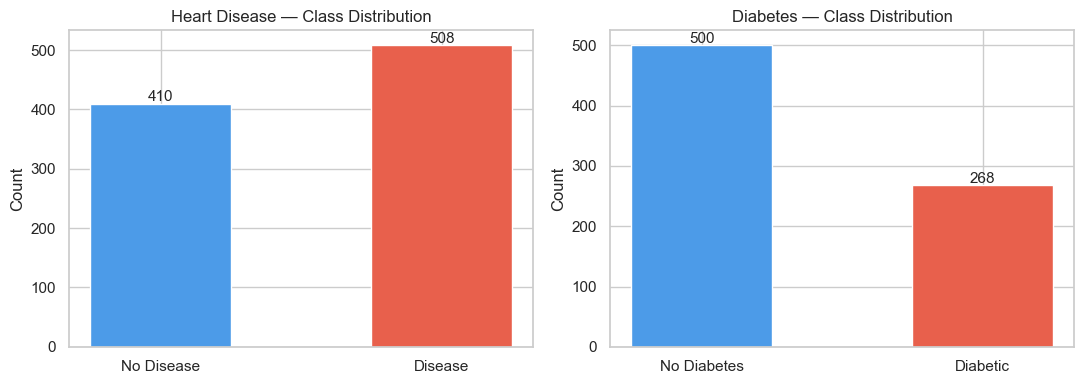

In [8]:
# ── Class Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, df, col, title, labels in [
    (axes[0], heart_df,    'HeartDisease', 'Heart Disease', ['No Disease', 'Disease']),
    (axes[1], diabetes_df, 'Outcome',      'Diabetes',      ['No Diabetes', 'Diabetic']),
]:
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(labels, counts.values, color=['#4C9BE8', '#E8604C'],
                  edgecolor='white', width=0.5)
    ax.set_title(f'{title} — Class Distribution', fontsize=12)
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                str(int(bar.get_height())), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=120)
plt.show()

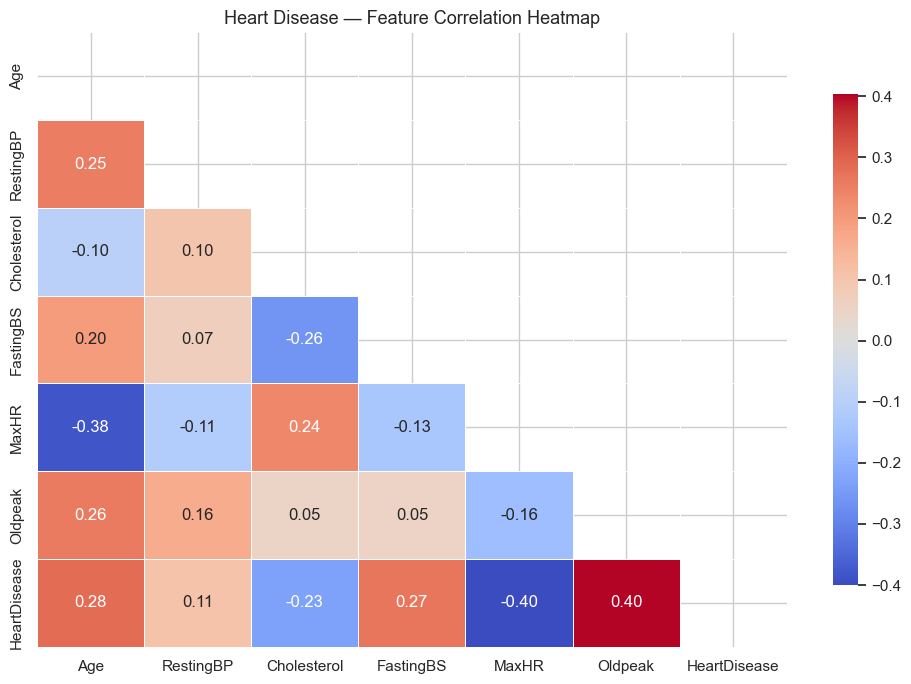

In [9]:
# ── Correlation Heatmap — Heart Disease ────────────────────────
numeric_heart = heart_df.select_dtypes(include=[np.number])
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(numeric_heart.corr(), dtype=bool))
sns.heatmap(numeric_heart.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Heart Disease — Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/heart_correlation.png', dpi=120)
plt.show()

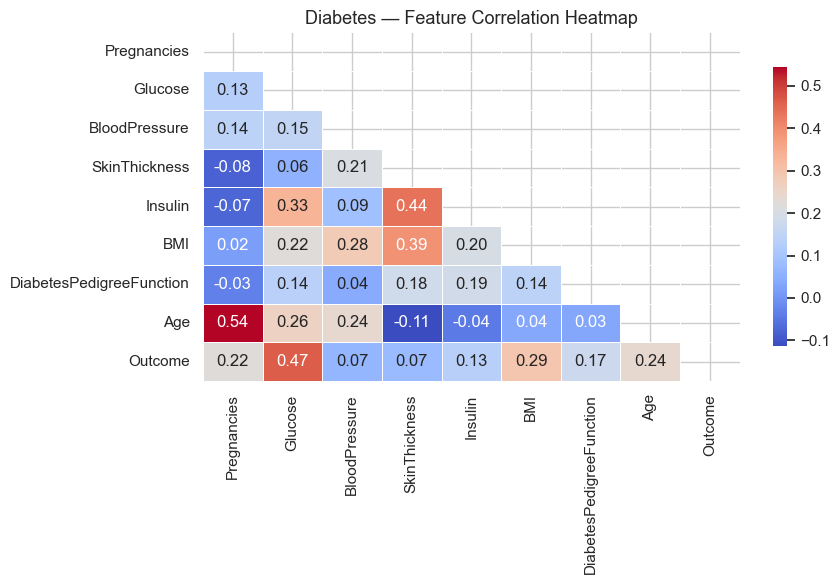

In [10]:
# ── Correlation Heatmap — Diabetes ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(diabetes_df.corr(), dtype=bool))
sns.heatmap(diabetes_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Diabetes — Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/diabetes_correlation.png', dpi=120)
plt.show()

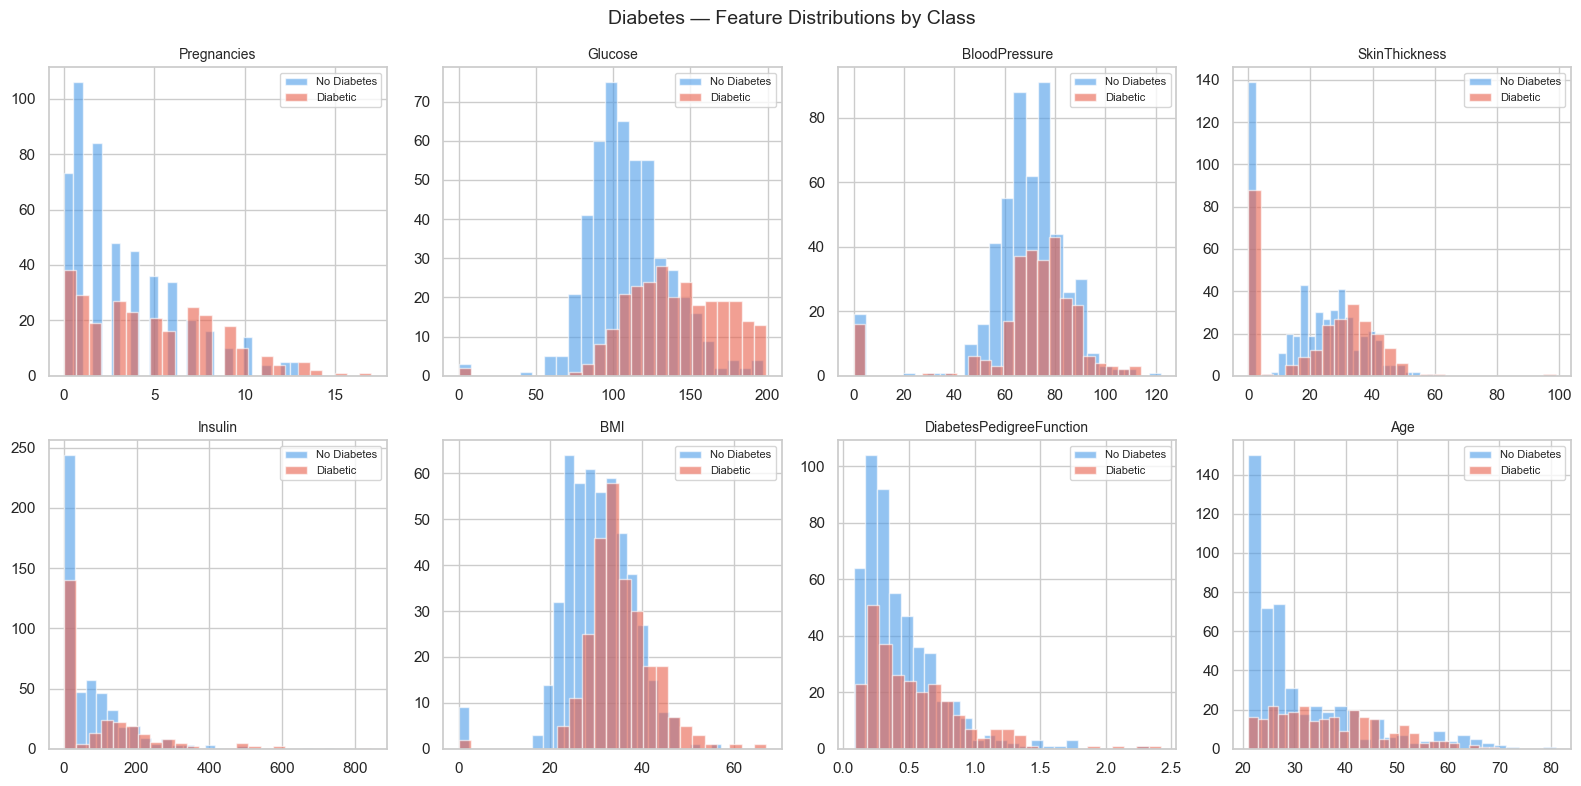

In [11]:
# ── Feature Distributions by Class — Diabetes ──────────────────
features_d = [c for c in diabetes_df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features_d):
    for val, color, label in [(0,'#4C9BE8','No Diabetes'), (1,'#E8604C','Diabetic')]:
        axes[i].hist(diabetes_df[diabetes_df['Outcome']==val][col],
                     bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

fig.suptitle('Diabetes — Feature Distributions by Class', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/diabetes_distributions.png', dpi=120)
plt.show()

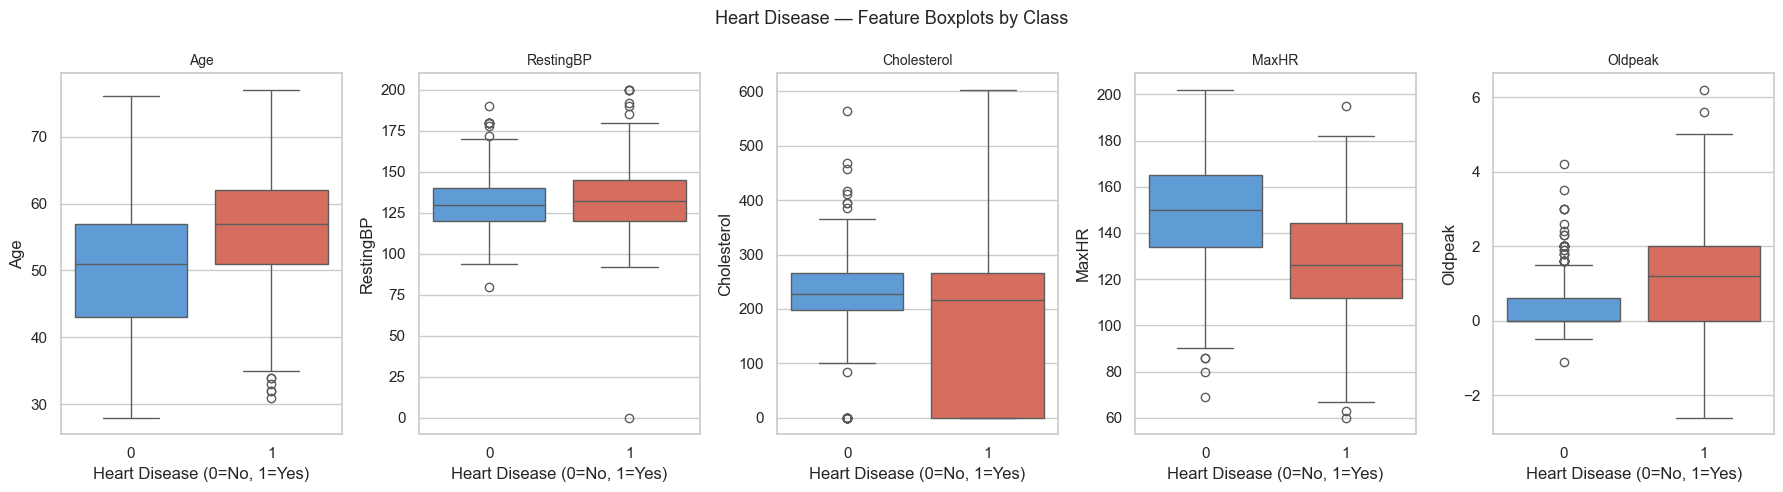

In [12]:
# ── Boxplots — Heart Disease Numeric Features ───────────────────
num_cols_h = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, num_cols_h):
    sns.boxplot(x='HeartDisease', y=col, data=heart_df,
                palette=['#4C9BE8', '#E8604C'], ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Heart Disease (0=No, 1=Yes)')

fig.suptitle('Heart Disease — Feature Boxplots by Class', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/heart_boxplots.png', dpi=120)
plt.show()

---
## 🔧 Step 3 — Preprocessing

Before feeding data into ML models, we need to:
1. **Encode** categorical columns (text → numbers)
2. **Fix invalid zeros** in the diabetes dataset (e.g. Glucose=0 is biologically impossible)
3. **Fill missing values** with the column median
4. **Scale** all features using StandardScaler (so no feature dominates due to scale)
5. **Split** into 80% training and 20% test sets

In [13]:
# ── Preprocess Heart Disease ────────────────────────────────────
heart = heart_df.copy()

# Encode categorical columns
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le = LabelEncoder()
for col in cat_cols:
    if col in heart.columns:
        heart[col] = le.fit_transform(heart[col])

X_h = heart.drop('HeartDisease', axis=1)
y_h = heart['HeartDisease']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h
)

scaler_h = StandardScaler()
X_train_h_sc = scaler_h.fit_transform(X_train_h)
X_test_h_sc  = scaler_h.transform(X_test_h)

joblib.dump(scaler_h,             '../models/heart_scaler.pkl')
joblib.dump(X_h.columns.tolist(), '../models/heart_features.pkl')

print('✅ Heart Disease preprocessing done!')
print(f'   Train: {X_train_h_sc.shape[0]} samples | Test: {X_test_h_sc.shape[0]} samples')
print(f'   Features: {X_train_h_sc.shape[1]}')

✅ Heart Disease preprocessing done!
   Train: 734 samples | Test: 184 samples
   Features: 11


In [14]:
# ── Preprocess Diabetes ─────────────────────────────────────────
diabetes = diabetes_df.copy()

# Replace biologically impossible zeros with NaN
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes[zero_cols] = diabetes[zero_cols].replace(0, np.nan)

print('Missing values after replacing zeros:')
print(diabetes.isnull().sum()[diabetes.isnull().sum() > 0])

# Fill NaN with median
diabetes.fillna(diabetes.median(numeric_only=True), inplace=True)
print('\nAfter filling with median — missing values:', diabetes.isnull().sum().sum())

X_d = diabetes.drop('Outcome', axis=1)
y_d = diabetes['Outcome']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d
)

scaler_d = StandardScaler()
X_train_d_sc = scaler_d.fit_transform(X_train_d)
X_test_d_sc  = scaler_d.transform(X_test_d)

joblib.dump(scaler_d,             '../models/diabetes_scaler.pkl')
joblib.dump(X_d.columns.tolist(), '../models/diabetes_features.pkl')

print('\n✅ Diabetes preprocessing done!')
print(f'   Train: {X_train_d_sc.shape[0]} samples | Test: {X_test_d_sc.shape[0]} samples')
print(f'   Features: {X_train_d_sc.shape[1]}')

Missing values after replacing zeros:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

After filling with median — missing values: 0

✅ Diabetes preprocessing done!
   Train: 614 samples | Test: 154 samples
   Features: 8


---
## 🤖 Step 4 — Train & Compare Models

We train **5 different ML models** on both datasets and compare them using:
- **Accuracy** — overall correct predictions
- **F1-Score** — balances precision & recall (best metric for medical data)
- **CV Mean** — 5-fold cross-validation (checks if model generalises well)

| Model | Strength |
|---|---|
| Logistic Regression | Simple, fast, interpretable baseline |
| Random Forest | Great accuracy, gives feature importance |
| XGBoost | Usually the best performer |
| SVM | Works well on smaller datasets |
| KNN | Simple distance-based comparison |

In [15]:
# ── Define all models ───────────────────────────────────────────
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}
print('✅ Models defined:', list(MODELS.keys()))

✅ Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM', 'KNN']


In [16]:
# ── Train & evaluate helper function ───────────────────────────
def train_all_models(X_train, X_test, y_train, y_test, dataset_name):
    results = {}
    print(f'\n Training models on: {dataset_name}')
    print(f"{'-'*55}")
    print(f"  {'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'CV Mean':>10}")
    print(f"  {'-'*55}")

    for name, model in MODELS.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)
        cv  = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()
        results[name] = {'accuracy': acc, 'f1': f1, 'cv_mean': cv, 'model': model}
        print(f"  {name:<25} {acc:>10.4f} {f1:>10.4f} {cv:>10.4f}")

    best_name  = max(results, key=lambda x: results[x]['f1'])
    best_model = results[best_name]['model']
    print(f'\n  ⭐ Best model: {best_name} (F1 = {results[best_name]["f1"]:.4f})')

    safe = dataset_name.lower().replace(' ', '_')
    joblib.dump(best_model, f'../models/{safe}_best_model.pkl')
    joblib.dump(best_name,  f'../models/{safe}_best_model_name.pkl')
    for name, res in results.items():
        key = name.lower().replace(' ', '_')
        joblib.dump(res['model'], f'../models/{safe}_{key}.pkl')

    return results, best_name

In [17]:
results_h, best_h = train_all_models(
    X_train_h_sc, X_test_h_sc, y_train_h.values, y_test_h.values, 'Heart Disease'
)


 Training models on: Heart Disease
-------------------------------------------------------
  Model                       Accuracy   F1-Score    CV Mean
  -------------------------------------------------------
  Logistic Regression           0.8696     0.8879     0.8627
  Random Forest                 0.8750     0.8889     0.8681
  XGBoost                       0.8696     0.8800     0.8427
  SVM                           0.8859     0.9014     0.8762
  KNN                           0.8913     0.9029     0.8577

  ⭐ Best model: KNN (F1 = 0.9029)


In [18]:
results_d, best_d = train_all_models(
    X_train_d_sc, X_test_d_sc, y_train_d.values, y_test_d.values, 'Diabetes'
)


 Training models on: Diabetes
-------------------------------------------------------
  Model                       Accuracy   F1-Score    CV Mean
  -------------------------------------------------------
  Logistic Regression           0.7078     0.5455     0.6497
  Random Forest                 0.7792     0.6600     0.6381
  XGBoost                       0.7597     0.6408     0.6126
  SVM                           0.7403     0.6000     0.6285
  KNN                           0.7532     0.6346     0.6099

  ⭐ Best model: Random Forest (F1 = 0.6600)


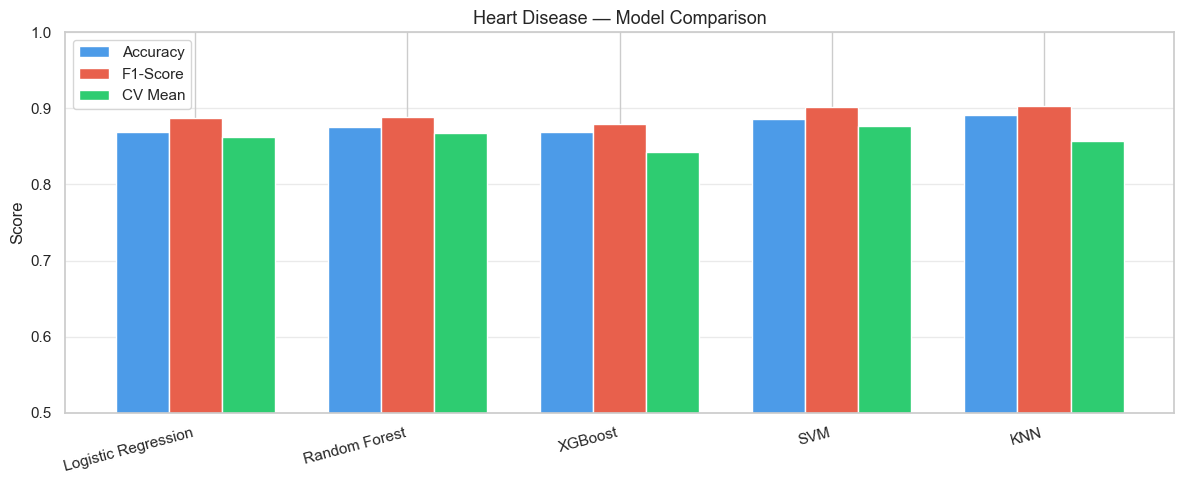

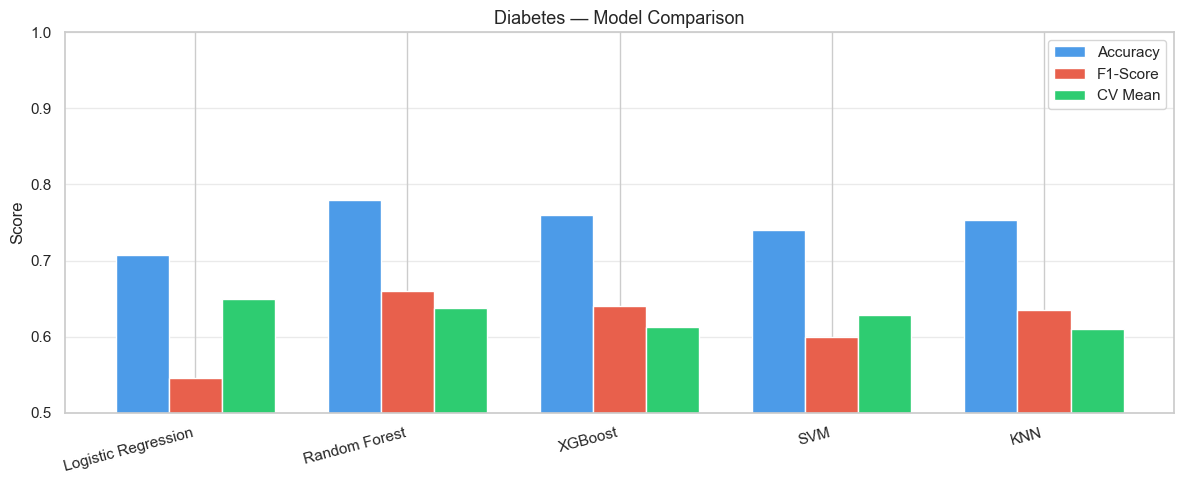

In [19]:
# ── Visual model comparison bar chart ──────────────────────────
def plot_model_comparison(results, dataset_name):
    names  = list(results.keys())
    accs   = [results[n]['accuracy'] for n in names]
    f1s    = [results[n]['f1']       for n in names]
    cvs    = [results[n]['cv_mean']  for n in names]

    x = np.arange(len(names))
    w = 0.25
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w, accs, w, label='Accuracy',  color='#4C9BE8', edgecolor='white')
    ax.bar(x,     f1s,  w, label='F1-Score',  color='#E8604C', edgecolor='white')
    ax.bar(x + w, cvs,  w, label='CV Mean',   color='#2ECC71', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel('Score')
    ax.set_title(f'{dataset_name} — Model Comparison', fontsize=13)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    safe = dataset_name.lower().replace(' ', '_')
    plt.savefig(f'../outputs/{safe}_model_comparison.png', dpi=120)
    plt.show()

plot_model_comparison(results_h, 'Heart Disease')
plot_model_comparison(results_d, 'Diabetes')

---
## 📈 Step 5 — Evaluate Best Models

Now we dive deep into the best model for each dataset:
- **Confusion Matrix** — shows true/false positives and negatives
- **Classification Report** — precision, recall, F1 per class
- **ROC Curve** — all 5 models compared on one chart
- **Feature Importance** — which features matter most?

In [ ]:
# ── Evaluation helper ───────────────────────────────────────────
def evaluate(results, X_test, y_test, dataset_name, class_labels):
    best_name  = max(results, key=lambda x: results[x]['f1'])
    best_model = results[best_name]['model']
    y_pred     = best_model.predict(X_test)

    print(f'\n=== {dataset_name} — Best Model: {best_name} ===')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=class_labels))

    colors = ['#4C9BE8','#E8604C','#2ECC71','#9B59B6','#F39C12']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
        ax=axes[0], colorbar=False, cmap='Blues'
    )
    axes[0].set_title(f'Confusion Matrix\n{best_name}', fontsize=11)

    # ROC curves
    for (name, res), color in zip(results.items(), colors):
        m = res['model']
        prob = m.predict_proba(X_test)[:,1] if hasattr(m,'predict_proba') else m.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, prob)
        roc_auc = auc(fpr, tpr)
        lw = 2.5 if name == best_name else 1.2
        axes[1].plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC={roc_auc:.3f})')
    axes[1].plot([0,1],[0,1],'k--',lw=0.8)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve — All Models', fontsize=11)
    axes[1].legend(loc='lower right', fontsize=8)

    # Feature importance (Random Forest)
    rf = results.get('Random Forest', {}).get('model')
    if rf and hasattr(rf, 'feature_importances_'):
        safe = dataset_name.lower().replace(' ', '_')
        feat_names = joblib.load(f'../models/{safe.split("_")[0]}_features.pkl')
        imp = rf.feature_importances_
        idx = np.argsort(imp)[::-1]
        axes[2].barh([feat_names[i] for i in idx], imp[idx],
                     color='#4C9BE8', edgecolor='white')
        axes[2].invert_yaxis()
        axes[2].set_xlabel('Importance')
        axes[2].set_title('Feature Importance\n(Random Forest)', fontsize=11)

    plt.suptitle(f'{dataset_name} — Full Evaluation', fontsize=13, y=1.01)
    plt.tight_layout()
    safe = dataset_name.lower().replace(' ','_')
    plt.savefig(f'../outputs/{safe}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()


=== Heart Disease — Best Model: KNN ===

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.87      0.88        82
     Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



FileNotFoundError: [Errno 2] No such file or directory: '../models/heart_disease_features.pkl'

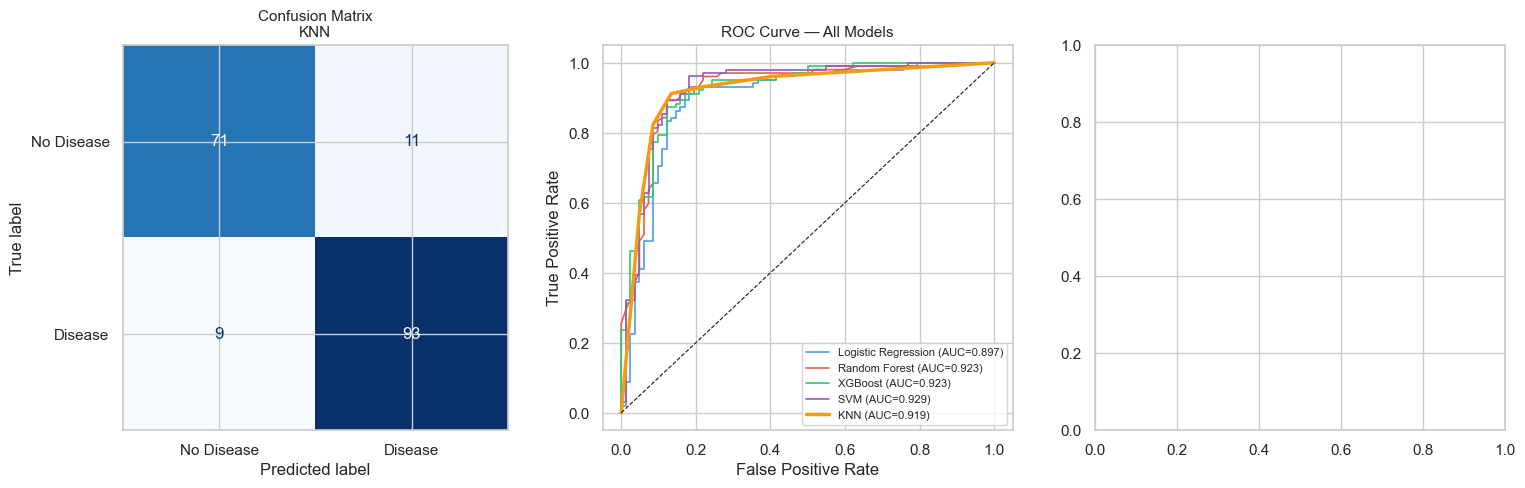

In [21]:
# Reload heart-trained models to avoid estimator overwrite between datasets
for name in results_h:
    model_key = name.lower().replace(' ', '_')
    results_h[name]['model'] = joblib.load(f'../models/heart_disease_{model_key}.pkl')

evaluate(results_h, X_test_h_sc, y_test_h.values,
         'Heart Disease', ['No Disease', 'Disease'])

In [ ]:
evaluate(results_d, X_test_d_sc, y_test_d.values,
         'Diabetes', ['No Diabetes', 'Diabetic'])

---
## 🔮 Step 6 — Predict for a New Patient

Now we use the saved best model to make a prediction on **custom patient values**.
Edit the dictionary below with real patient data to test it out.

In [ ]:
# ── Heart Disease Prediction ────────────────────────────────────
# Edit these values for a new patient
# Sex: 1=Male, 0=Female | ExerciseAngina: 1=Yes, 0=No
new_heart_patient = {
    'Age':             54,
    'Sex':              1,
    'ChestPainType':    1,
    'RestingBP':      130,
    'Cholesterol':    250,
    'FastingBS':        0,
    'RestingECG':       1,
    'MaxHR':          150,
    'ExerciseAngina':   0,
    'Oldpeak':        1.5,
    'ST_Slope':         2,
}

features_h = joblib.load('../models/heart_features.pkl')
scaler_h   = joblib.load('../models/heart_scaler.pkl')
model_h    = joblib.load('../models/heart_disease_best_model.pkl')
model_name_h = joblib.load('../models/heart_disease_best_model_name.pkl')

X_new = np.array([[new_heart_patient[f] for f in features_h]])
X_new_sc = scaler_h.transform(X_new)
pred  = model_h.predict(X_new_sc)[0]
proba = model_h.predict_proba(X_new_sc)[0]

print(f'Model used: {model_name_h}')
print(f'\n{"="*45}')
result_str = '⚠️  HIGH RISK — Heart Disease Likely' if pred == 1 else '✅  LOW RISK — No Heart Disease'
print(f'  RESULT : {result_str}')
print(f'  No Disease: {proba[0]*100:.1f}%  |  Disease: {proba[1]*100:.1f}%')
print(f'{"="*45}')
print('\n⚕️  Note: This is NOT a medical diagnosis. Consult a doctor.')

In [ ]:
# ── Diabetes Prediction ─────────────────────────────────────────
# Edit these values for a new patient
new_diabetes_patient = {
    'Pregnancies':              2,
    'Glucose':                130,
    'BloodPressure':           72,
    'SkinThickness':           28,
    'Insulin':                100,
    'BMI':                   30.5,
    'DiabetesPedigreeFunction': 0.45,
    'Age':                     35,
}

features_d = joblib.load('../models/diabetes_features.pkl')
scaler_d   = joblib.load('../models/diabetes_scaler.pkl')
model_d    = joblib.load('../models/diabetes_best_model.pkl')
model_name_d = joblib.load('../models/diabetes_best_model_name.pkl')

X_new_d = np.array([[new_diabetes_patient[f] for f in features_d]])
X_new_d_sc = scaler_d.transform(X_new_d)
pred_d  = model_d.predict(X_new_d_sc)[0]
proba_d = model_d.predict_proba(X_new_d_sc)[0]

print(f'Model used: {model_name_d}')
print(f'\n{"="*45}')
result_str = '⚠️  HIGH RISK — Diabetic' if pred_d == 1 else '✅  LOW RISK — Not Diabetic'
print(f'  RESULT : {result_str}')
print(f'  No Diabetes: {proba_d[0]*100:.1f}%  |  Diabetic: {proba_d[1]*100:.1f}%')
print(f'{"="*45}')
print('\n⚕️  Note: This is NOT a medical diagnosis. Consult a doctor.')

---
## ✅ Summary & Next Steps

### What we built:
- Loaded and explored two real medical datasets
- Cleaned and preprocessed data (encoding, scaling, fixing invalid values)
- Trained and compared 5 ML models on both datasets
- Evaluated using Accuracy, F1-Score, ROC-AUC, and Confusion Matrix
- Built a prediction function for new patient data

### How to improve further:
| Improvement | How |
|---|---|
| Handle class imbalance | Add SMOTE from `imblearn` library |
| Tune hyperparameters | Use `GridSearchCV` or `RandomizedSearchCV` |
| Better neural net | Try a simple `Keras` sequential model |
| Explainability | Add `SHAP` values to explain predictions |
| Deploy as app | Wrap model in a `Streamlit` web app |

---
*Project by: [ADITYA KUMAR, ADIL RASHEED, LAKSHAY] | Dataset sources: Kaggle & UCI ML Repository*